# LightSync: final dataset preparation

**IIT Guwahati outdoor and corridor lighting prototype**

This notebook rebuilds clean, documented datasets from the original solar CSV and completed field-entry workbook. Run all cells in order in VS Code with the project's Python environment selected. It uses local files only.

The pipeline preserves raw evidence, separates historical solar readings from the September 2026 switching observations, and exports CSV plus Parquet. It does **not** train a lighting model or fabricate current radiation, lux readings, or optimal switching labels.

See `README.md` for setup and `docs/DATA_NOTES.md` for interpretation. All quantities labelled energy are estimates of consumption; they are not energy-waste or savings claims.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'config/project_config.json').exists():
    ROOT = ROOT / 'LightSync'
assert (ROOT / 'config/project_config.json').exists(), 'Open this notebook from the LightSync project folder.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.prepare_data import build, sha256
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Project:', ROOT.name)


Project: LightSync


## 1. Inspect the source files

The solar file has five metadata lines before its header. Missing station values use `--`. Read just the eight meaningful columns of the workbook; its extra blank/exported columns are excluded. No original file is edited.

Dates in the weather export use month/day/year; switching dates come from typed Excel dates. Station timestamps are interpreted as campus local time, pending provider confirmation.

In [2]:
raw_solar = pd.read_csv(ROOT / 'data/raw/solar_station_original.csv', skiprows=5,
                        encoding='cp1252', na_values=['--'], low_memory=False)
raw_entries = pd.read_excel(ROOT / 'data/raw/lighting_observations_original.xlsx',
                            sheet_name='Fill here', usecols='A:H', nrows=20)
print(f'Solar source: {len(raw_solar):,} rows, {len(raw_solar.columns)} columns')
display(raw_entries)
display(raw_solar.iloc[:5, [0, 13, 16, 40, 42]])


Solar source: 33,441 rows, 47 columns


,Location name / landmark,Type,Main obstruction,Number of lights,ON date,Observed ON time,OFF date,Observed OFF time
0,IITG Border Road,Street lights,Mixed obstructions,400,2026-09-25,16:45:00,2026-09-26,05:30:00
1,IITG Border Road,Street lights,Mixed obstructions,400,2026-09-26,16:45:00,2026-09-27,05:30:00
2,Surjyamukhi Road,Street lights,Dense trees,150,2026-09-25,16:45:00,2026-09-26,05:30:00
3,Surjyamukhi Road,Street lights,Dense trees,150,2026-09-26,16:45:00,2026-09-27,05:30:00
4,IIT Road,Street lights,Open sky / none,50,2026-09-25,16:30:00,2026-09-26,05:45:00
5,IIT Road,Street lights,Open sky / none,50,2026-09-26,16:30:00,2026-09-27,05:45:00
6,Radhasura Road,Street lights,Dense trees,80,2026-09-25,17:00:00,2026-09-26,05:45:00
7,Radhasura Road,Street lights,Dense trees,80,2026-09-26,17:00:00,2026-09-27,05:45:00
8,Godhuli Gopal Road,Street lights,Dense trees,40,2026-09-25,17:00:00,2026-09-26,05:30:00
9,Godhuli Gopal Road,Street lights,Dense trees,40,2026-09-26,17:00:00,2026-09-27,05:30:00


,Date & Time,Temp - °C,Hum - %,Rain - mm,Solar Rad - W/m^2
0,3/7/24 12:00 AM,21.0,59.0,0.0,0.0
1,3/7/24 12:15 AM,21.0,59.0,0.0,0.0
2,3/7/24 12:30 AM,21.0,59.0,0.0,0.0
3,3/7/24 12:45 AM,21.0,61.0,0.0,0.0
4,3/7/24 1:00 AM,20.0,64.0,0.0,0.0


## 2. Rebuild the final datasets

The reusable pipeline validates timestamps and counts, preserves missing measurements, adds explicit missing-grid rows, assigns location IDs, incorporates fixture-type corrections, and calculates manual energy bounds. It exports schemas, source checksums and a quality report.

Working-light scenarios use 3–4 potentially nonworking floodlights on Border Road and 1–2 on each other road. Corridors use installed counts because no failures were reported. These bounds do not establish failures on either specific observation night.

Fixed power inputs are stored in `config/project_config.json` with manufacturer provenance. Exact installed models are not verified. Campus proxy coordinates support astronomy; actual road/corridor coordinate fields remain missing.

In [3]:
report = build(ROOT)
print(json.dumps(report, indent=2))


{
  "status": "passed",
  "solar": {
    "source_rows": 33441,
    "source_measurement_columns": 46,
    "first_timestamp": "2024-03-07 00:00:00+05:30",
    "last_timestamp": "2025-03-07 00:00:00+05:30",
    "valid_radiation_rows": 20193,
    "missing_radiation_in_source_rows": 13248,
    "invalid_nonmissing_radiation_rows": 0,
    "expected_grid_rows": 35041,
    "missing_source_rows": 1600,
    "last_valid_radiation_timestamp": "2025-01-15 01:45:00+05:30",
    "split_counts": {
      "train": 13840,
      "test": 4533,
      "validation": 1820
    },
    "negative_radiation_rows": 0,
    "synthetic_measurements": 0
  },
  "lighting": {
    "locations": 10,
    "observed_intervals": 20,
    "installed_fixtures": 2425,
    "working_fixtures_min": 2407,
    "working_fixtures_max": 2415,
    "observed_nights": [
      "2026-09-25",
      "2026-09-26"
    ],
    "manual_energy_total_kwh_min": 3745.7549999999997,
    "manual_energy_total_kwh_max": 3766.965,
    "note": "Totals cover only t

## 3. Review locations and observations

Inventory has one row per location. Two observation nights remain two records; they must not double the installed count. Border Road floodlights are separate from the other roads. The obstruction labels are descriptive and do not imply a known lux attenuation factor.

In [4]:
def load(name):
    return pd.read_parquet(ROOT / 'data/processed' / f'{name}.parquet')

locations = load('locations')
observations = load('switching_observations')
energy = load('manual_energy_baseline')
display(locations[['location_id', 'location_name', 'fixture_type', 'main_obstruction',
                   'installed_lights', 'working_lights_min', 'working_lights_max', 'rated_power_w']])
display(observations[['observation_id', 'on_timestamp_local', 'off_timestamp_local',
                      'manual_on_duration_hours']])


,location_id,location_name,fixture_type,main_obstruction,installed_lights,working_lights_min,working_lights_max,rated_power_w
0,LOC001,IITG Border Road,floodlight,Mixed obstructions,400,396,397,200
1,LOC002,Surjyamukhi Road,streetlight,Dense trees,150,148,149,90
2,LOC003,IIT Road,streetlight,Open sky / none,50,48,49,90
3,LOC004,Radhasura Road,streetlight,Dense trees,80,78,79,90
4,LOC005,Godhuli Gopal Road,streetlight,Dense trees,40,38,39,90
5,LOC006,Umiam Hostel Road,streetlight,Sparse trees,15,13,14,90
6,LOC007,KV Road,streetlight,Dense trees,30,28,29,90
7,LOC008,Disang Road,streetlight,Open sky / none,40,38,39,90
8,LOC009,Lohit Hostel,tube_light,Roof / covered,720,720,720,20
9,LOC010,Disang Hostel,tube_light,Roof / covered,900,900,900,20


,observation_id,on_timestamp_local,off_timestamp_local,manual_on_duration_hours
0,LOC003_20260925,2026-09-25 16:30:00+05:30,2026-09-26 05:45:00+05:30,13.25
1,LOC001_20260925,2026-09-25 16:45:00+05:30,2026-09-26 05:30:00+05:30,12.75
2,LOC002_20260925,2026-09-25 16:45:00+05:30,2026-09-26 05:30:00+05:30,12.75
3,LOC006_20260925,2026-09-25 16:45:00+05:30,2026-09-26 05:30:00+05:30,12.75
4,LOC007_20260925,2026-09-25 16:45:00+05:30,2026-09-26 05:30:00+05:30,12.75
5,LOC004_20260925,2026-09-25 17:00:00+05:30,2026-09-26 05:45:00+05:30,12.75
6,LOC005_20260925,2026-09-25 17:00:00+05:30,2026-09-26 05:30:00+05:30,12.50
7,LOC008_20260925,2026-09-25 17:00:00+05:30,2026-09-26 05:45:00+05:30,12.75
8,LOC009_20260925,2026-09-25 17:00:00+05:30,2026-09-26 05:45:00+05:30,12.75
9,LOC010_20260925,2026-09-25 17:00:00+05:30,2026-09-26 05:45:00+05:30,12.75


## 4. Solar coverage and gaps

The full timeline includes dates with no rows and the final partial export day. Missing radiation is not replaced by zero. This matters near dawn/dusk, where an invented zero would change a predicted switching decision. Coverage denominators use only slots within the actual export interval.

,expected_slots,valid_targets,coverage_percent
month_label,,,
2024-03,2400,1828,76.17
2024-04,2880,2117,73.51
2024-05,2976,2749,92.37
2024-06,2880,1867,64.83
2024-07,2976,2877,96.67
2024-08,2976,2402,80.71
2024-09,2880,1820,63.19
2024-10,2976,1328,44.62
2024-11,2880,2379,82.60


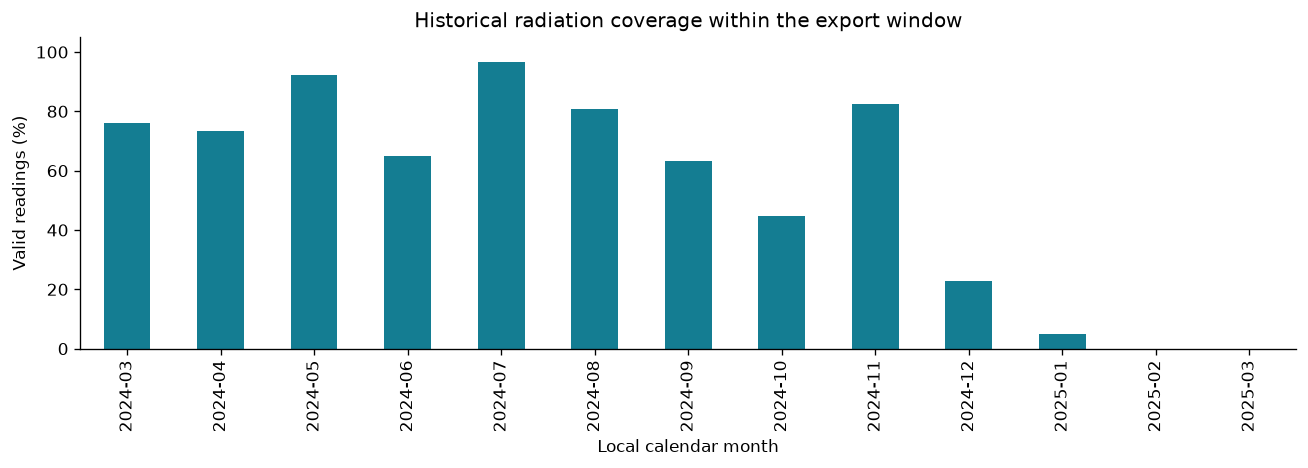

In [5]:
weather = load('solar_weather_clean')
grid = load('solar_15min_grid')
coverage = load('solar_daily_coverage')
model_data = load('solar_model_input')
monthly = grid.assign(month_label=grid.timestamp_local.dt.strftime('%Y-%m')).groupby('month_label').agg(
    expected_slots=('radiation_valid', 'size'), valid_targets=('radiation_valid', 'sum'))
monthly['coverage_percent'] = 100 * monthly.valid_targets / monthly.expected_slots
display(monthly.round(2))
fig, ax = plt.subplots(figsize=(11, 4))
monthly.coverage_percent.plot.bar(ax=ax, color='#147d92')
ax.set(title='Historical radiation coverage within the export window',
       ylabel='Valid readings (%)', xlabel='Local calendar month', ylim=(0, 105))
fig.tight_layout()
fig.savefig(ROOT / 'reports/figures/solar_coverage.png')
plt.show()


## 5. Chronological model inputs

Train: March–August 2024. Validation: September 2024. Test: October 2024 onward, ending wherever valid radiation ends. Training samples include valid zeros, so later model evaluation must report daytime and dawn/dusk errors separately.

Features are calendar cycles and calculated solar elevation. The target is historical radiation in W/m², not lux. No current-weather feature or target-derived high-radiation value is supplied. Do not shuffle these rows for model selection. This is a seasonal-profile dataset, not evidence of accurate current cloud forecasts.

In [6]:
display(model_data.groupby('split', sort=False).agg(
    rows=('solar_radiation_w_m2', 'size'), start=('timestamp_local', 'min'),
    end=('timestamp_local', 'max'), positive_targets=('solar_radiation_w_m2', lambda s: int(s.gt(0).sum()))))
features = json.loads((ROOT / 'config/model_features.json').read_text())
print('Features:', features['features'])
display(model_data.head())


,rows,start,end,positive_targets
split,,,,
train,13840,2024-03-07 00:00:00+05:30,2024-08-31 23:45:00+05:30,7240
validation,1820,2024-09-01 00:00:00+05:30,2024-09-29 03:15:00+05:30,875
test,4533,2024-10-01 07:45:00+05:30,2025-01-15 01:45:00+05:30,1712


Features: ['minute_of_day', 'day_of_year', 'month', 'time_sin', 'time_cos', 'year_sin', 'year_cos', 'solar_elevation_deg']


,timestamp_local,source_row_number,minute_of_day,day_of_year,month,time_sin,time_cos,year_sin,year_cos,solar_elevation_deg,solar_radiation_w_m2,split
0,2024-03-07 00:00:00+05:30,7,0,67,3,0.000000,1.000000,0.905702,0.423914,-68.187924,0.0,train
1,2024-03-07 00:15:00+05:30,8,15,67,3,0.065403,0.997859,0.905702,0.423914,-66.916820,0.0,train
2,2024-03-07 00:30:00+05:30,9,30,67,3,0.130526,0.991445,0.905702,0.423914,-65.189158,0.0,train
3,2024-03-07 00:45:00+05:30,10,45,67,3,0.195090,0.980785,0.905702,0.423914,-63.093240,0.0,train
4,2024-03-07 01:00:00+05:30,11,60,67,3,0.258819,0.965926,0.905702,0.423914,-60.708628,0.0,train


## 6. Campus astronomy for the observation dates

Astral calculates sunrise, sunset and civil twilight for a shared campus proxy. These are astronomical event times, not validated light-switching times. Local obstruction, clouds and corridor geometry require a later daylight model and validation. The proxy is not the exact weather sensor or lamp location.

In [7]:
astronomy = load('astronomy_daily')
observation_dates = set(observations.on_timestamp_local.dt.strftime('%Y-%m-%d')) | set(observations.off_timestamp_local.dt.strftime('%Y-%m-%d'))
display(astronomy[astronomy.local_date.isin(observation_dates)][[
    'local_date', 'civil_dawn_local', 'sunrise_local', 'sunset_local', 'civil_dusk_local']])


,local_date,civil_dawn_local,sunrise_local,sunset_local,civil_dusk_local
0,2026-09-25,2026-09-25 04:49:37.240878+05:30,2026-09-25 05:13:06.270433+05:30,2026-09-25 17:16:32.700201+05:30,2026-09-25 17:40:00.160917+05:30
1,2026-09-26,2026-09-26 04:50:02.525976+05:30,2026-09-26 05:13:31.443102+05:30,2026-09-26 17:15:26.094754+05:30,2026-09-26 17:38:53.487045+05:30
2,2026-09-27,2026-09-27 04:50:27.895591+05:30,2026-09-27 05:13:56.781788+05:30,2026-09-27 17:14:19.679924+05:30,2026-09-27 17:37:47.085186+05:30


## 7. Estimated manual-schedule consumption

`energy_kWh = working_fixtures × rated_power_W × elapsed_ON_hours / 1000`

The estimate presumes continuous ON operation between the observed endpoints and a common schedule for the counted fixtures. Lower/upper bounds reflect working-light counts only, not all power or timing uncertainty. This is total consumption under the observed schedule; it is **not** avoidable waste. No annual extrapolation is made from two nights.

Later, compare manual and recommended intervals using the same working count. Report excess ON energy and extra energy needed to fix underlighting separately; net savings is their difference. Cost and carbon factors are currently unset.

,manual_energy_kwh_min,manual_energy_kwh_max
night_start_date,,
2026-09-25,1872.878,1883.482
2026-09-26,1872.878,1883.482


,manual_energy_kwh_min,manual_energy_kwh_max,location_name
location_id,,,
LOC001,2019.600,2024.700,IITG Border Road
LOC002,339.660,341.955,Surjyamukhi Road
LOC003,114.480,116.865,IIT Road
LOC004,179.010,181.305,Radhasura Road
LOC005,85.500,87.750,Godhuli Gopal Road
LOC006,29.835,32.130,Umiam Hostel Road
LOC007,64.260,66.555,KV Road
LOC008,87.210,89.505,Disang Road
LOC009,367.200,367.200,Lohit Hostel


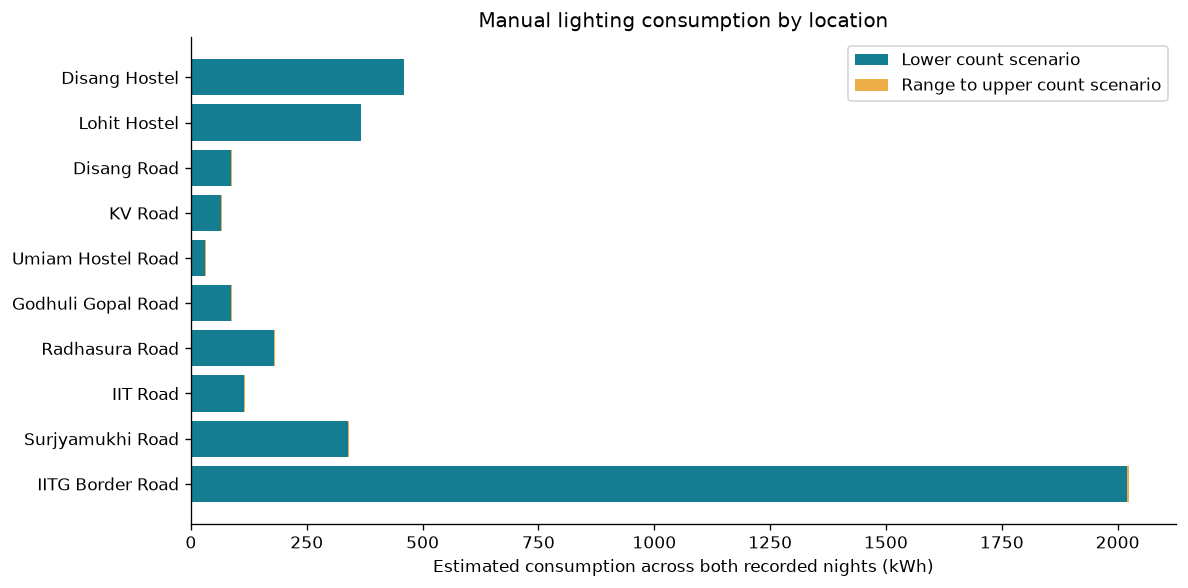

In [8]:
night_totals = energy.groupby('night_start_date')[['manual_energy_kwh_min', 'manual_energy_kwh_max']].sum()
display(night_totals.round(3))
per_location = energy.groupby('location_id')[['manual_energy_kwh_min', 'manual_energy_kwh_max']].sum().join(
    locations.set_index('location_id')['location_name'])
display(per_location.round(3))
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(per_location))
ax.barh(y, per_location.manual_energy_kwh_min, color='#147d92', label='Lower count scenario')
ax.barh(y, per_location.manual_energy_kwh_max - per_location.manual_energy_kwh_min,
        left=per_location.manual_energy_kwh_min, color='#edae49', label='Range to upper count scenario')
ax.set_yticks(y, per_location.location_name)
ax.set(xlabel='Estimated consumption across both recorded nights (kWh)', title='Manual lighting consumption by location')
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(ROOT / 'reports/figures/manual_consumption.png')
plt.show()


## 8. Validate saved datasets and source preservation

Checks cover keys, foreign-key joins, timing, missingness, working-count bounds, chronology, formula reconciliation, source checksums and CSV/Parquet row parity. They verify the preparation, not the physical accuracy of the inputs.

In [9]:
assert locations.location_id.is_unique
assert observations.observation_id.is_unique
assert set(observations.location_id) <= set(locations.location_id)
assert (observations.off_timestamp_local > observations.on_timestamp_local).all()
assert locations.working_lights_min.between(0, locations.working_lights_max).all()
assert (locations.working_lights_max <= locations.installed_lights).all()
assert grid.timestamp_local.is_unique and grid.timestamp_local.is_monotonic_increasing
assert grid.timestamp_local.diff().dropna().eq(pd.Timedelta(minutes=15)).all()
assert grid.loc[~grid.source_row_present, 'solar_radiation_w_m2'].isna().all()
assert weather.solar_radiation_w_m2.isna().sum() == raw_solar['Solar Rad - W/m^2'].isna().sum()
np.testing.assert_allclose(weather.solar_radiation_w_m2.to_numpy(),
                          raw_solar['Solar Rad - W/m^2'].to_numpy(), equal_nan=True)
assert len(model_data) == int(weather.radiation_valid.sum())
assert model_data[features['features'] + [features['target']]].notna().all().all()
assert model_data.loc[model_data.split.eq('train'), 'timestamp_local'].max() < model_data.loc[model_data.split.eq('validation'), 'timestamp_local'].min()
assert model_data.loc[model_data.split.eq('validation'), 'timestamp_local'].max() < model_data.loc[model_data.split.eq('test'), 'timestamp_local'].min()
assert weather.timestamp_local.max() < observations.on_timestamp_local.min()
for bound in ['min', 'max']:
    expected = energy[f'working_lights_{bound}'] * energy.rated_power_w * energy.manual_on_duration_hours / 1000
    np.testing.assert_allclose(energy[f'manual_energy_kwh_{bound}'], expected)
for entry in json.loads((ROOT / 'reports/source_manifest.json').read_text()):
    assert sha256(ROOT / entry['path']) == entry['sha256']
manifest = json.loads((ROOT / 'reports/dataset_manifest.json').read_text())
for entry in manifest:
    csv = pd.read_csv(ROOT / 'data/processed' / f"{entry['dataset']}.csv")
    parquet = load(entry['dataset'])
    assert len(csv) == len(parquet) == entry['rows']
    assert list(csv.columns) == list(parquet.columns)
    for file in entry['files']:
        assert sha256(ROOT / file['path']) == file['sha256']
print('All dataset validation checks passed.')
display(pd.DataFrame([{k: v for k, v in entry.items() if k != 'files'} for entry in manifest]))


C:\Users\kakre\AppData\Local\Temp\ipykernel_39584\3665950610.py:25: DtypeWarning: Columns (0: prevailing_wind_direction, 1: high_wind_direction) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv(ROOT / 'data/processed' / f"{entry['dataset']}.csv")


All dataset validation checks passed.


,dataset,rows,columns
0,solar_weather_clean,33441,53
1,solar_15min_grid,35041,16
2,solar_model_input,20193,12
3,solar_daily_coverage,366,8
4,locations,10,26
5,switching_observations,20,11
6,manual_energy_baseline,20,12
7,astronomy_daily,3,10


## 9. Continue with the prototype

1. Train a simple radiation baseline and compare gradient boosting using the chronological partitions.
2. Add a separately sourced current weather forecast if predicting actual upcoming conditions.
3. Define daylight-transfer scenarios for obstruction categories; calibrate with local lux measurements before treating lux as measured or operationally verified.
4. Derive ON/OFF recommendations with conservative thresholds and persistence; evaluate dusk/dawn performance.
5. Compare schedules to estimate excess energy, underlighting correction energy and net savings. Add a sourced tariff and carbon factor.

The dataset package contains no synthetic measurements and no fabricated savings. Review `reports/data_quality.md` and `docs/DATA_DICTIONARY.csv` when integrating the model.